# Tiền xử lý UNSW-NB15 — Phiên bản chuẩn cho QSVM-IDS

Pipeline tiền xử lý cho dataset **UNSW-NB15** (port từ NSL-KDD), giữ chuẩn
zero-leakage và tương thích downstream với SelectKBest / PCA / QSVM.

| Cột nhãn | Ý nghĩa | Dùng cho |
|----------|---------|----------|
| `label_binary` | 0 = Normal, 1 = Attack | Train/eval QSVM (C1–C3) |
| `label_multiclass` | Tên attack category (Generic, Exploits, Fuzzers, ...) | Phân tích chi tiết (C4) |
| `attack_category` | Trùng `label_multiclass` (UNSW không có level chi tiết hơn) | Stratified sampling đúng cách |

**Khác biệt với NSL-KDD:**
- Input là **parquet** (đã được pre-cleaned thượng nguồn — không có `id`).
- 3 categorical: `proto`, `service`, `state` (NSL-KDD: `protocol_type`, `service`, `flag`).
- Train **skew về phía Attack** (~68% attack vs 32% normal) — ngược chiều NSL-KDD.
- Rare attacks: `Worms` (130 mẫu), `Shellcode`, `Backdoor`, `Analysis`.
- `proto` có ~133 giá trị → bùng nổ chiều sau OHE; alignment train/test bắt buộc.


## 0. Import & kiểm tra phiên bản

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
import random

warnings.filterwarnings('ignore')

# --- THIẾT LẬP GLOBAL SEED ĐỂ ĐẢM BẢO REPRODUCIBLE ---
SEED = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)
# -----------------------------------------------------

from sklearn.preprocessing import MinMaxScaler

print(f"Pandas    : {pd.__version__}")
print(f"NumPy     : {np.__version__}")
print(f"Scikit    : {__import__('sklearn').__version__}")


Pandas    : 2.3.3
NumPy     : 2.4.3
Scikit    : 1.7.2


## 1. Cấu hình — chỉnh đường dẫn tại đây

In [2]:
# ── Đường dẫn dữ liệu gốc (parquet) ──
TRAIN_PATH = '../data/unsw_nb15/raw/UNSW_NB15_training-set.parquet'
TEST_PATH  = '../data/unsw_nb15/raw/UNSW_NB15_testing-set.parquet'

# ── Thư mục lưu output ──
OUTPUT_DIR = '../data/unsw_nb15/processed_data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Categorical columns trong UNSW-NB15 ──
CATEGORICAL_COLS = ['proto', 'service', 'state']

# ── Cột target gốc và cột nhãn output (giữ tên như NSL-KDD để downstream tương thích) ──
RAW_LABEL_COL      = 'label'        # binary 0/1
RAW_ATTACK_CAT_COL = 'attack_cat'   # 10 loại: Normal, Generic, Exploits, ...
LABEL_COLS         = ['label_binary', 'label_multiclass', 'attack_category']

# ── Cột id (nếu có trong file gốc) — bị drop ──
ID_COLS = ['id']

# ── Rare attack categories trong UNSW-NB15 (< 2% train) ──
RARE_CATEGORIES = ('Analysis', 'Backdoor', 'Shellcode', 'Worms')

print("Cấu hình OK")
print(f"  Train path : {TRAIN_PATH}")
print(f"  Test path  : {TEST_PATH}")
print(f"  Output dir : {OUTPUT_DIR}")
print(f"  Rare cats  : {RARE_CATEGORIES}")


Cấu hình OK
  Train path : ../data/unsw_nb15/raw/UNSW_NB15_training-set.parquet
  Test path  : ../data/unsw_nb15/raw/UNSW_NB15_testing-set.parquet
  Output dir : ../data/unsw_nb15/processed_data
  Rare cats  : ('Analysis', 'Backdoor', 'Shellcode', 'Worms')


## 2. Hàm tiền xử lý

**Quy tắc zero-leakage (BẮT BUỘC):**
1. Tách `(features, labels)` **TRƯỚC** mọi transformation — tránh OHE/scale ăn vào nhãn.
2. `pd.get_dummies` chạy **độc lập** trên train và test, sau đó dùng
   `X_train.align(X_test, join='left', axis=1, fill_value=0)`:
   - Category trong train, không trong test → test fill 0 ✓
   - Category trong test, không trong train → drop ✓
3. `MinMaxScaler.fit(X_train)` chỉ trên train, `transform(X_test)` + `np.clip(0, 1)` cho test.


In [3]:
def add_label_columns(df, split_name=''):
    """Tạo 3 cột nhãn chuẩn từ cột 'label' (binary) và 'attack_cat'.

    Quy ước trùng tên với NSL-KDD pipeline để các notebook downstream
    (selectkbest, pca, c2..c6) đọc được mà không cần đổi schema.
    """
    df = df.copy()
    df['label_binary']     = df[RAW_LABEL_COL].astype(int)
    # UNSW-NB15 không có level chi tiết hơn attack_cat → multiclass = attack_cat
    df['label_multiclass'] = df[RAW_ATTACK_CAT_COL].astype(str)
    df['attack_category']  = df[RAW_ATTACK_CAT_COL].astype(str)

    nan_cnt = df['attack_category'].isna().sum()
    if nan_cnt > 0:
        print(f"  ⚠  [{split_name}] {nan_cnt} mẫu thiếu attack_cat → gán 'Unknown'")
        df['attack_category']  = df['attack_category'].fillna('Unknown')
        df['label_multiclass'] = df['label_multiclass'].fillna('Unknown')
    return df


def preprocess_unsw_nb15(train_path, test_path):
    """Tiền xử lý UNSW-NB15: load → drop id/attack_cat khỏi X → OHE → align → MinMaxScale.

    Returns
    -------
    train_proc : DataFrame  — features + 3 cột nhãn
    test_proc  : DataFrame  — features + 3 cột nhãn
    scaler     : MinMaxScaler đã fit trên train (dùng lại cho dataset mới)
    """
    # ── 1. Load ──
    print("[1/5] Đang load dữ liệu parquet...")
    train_df = pd.read_parquet(train_path)
    test_df  = pd.read_parquet(test_path)

    # Drop cột id nếu tồn tại (file đã được pre-cleaned thượng nguồn — thường không có)
    for col in ID_COLS:
        if col in train_df.columns:
            train_df = train_df.drop(columns=col)
        if col in test_df.columns:
            test_df  = test_df.drop(columns=col)
    print(f"   Train raw : {train_df.shape} | Test raw : {test_df.shape}")

    # ── 2. Tạo các cột nhãn chuẩn (TRƯỚC mọi thao tác feature) ──
    print("[2/5] Tạo cột nhãn...")
    train_df = add_label_columns(train_df, 'Train')
    test_df  = add_label_columns(test_df,  'Test')

    # ── 3. Tách features và nhãn để tránh rò rỉ ──
    # X = mọi cột TRỪ:
    #   - label gốc (binary 0/1)              → đã copy sang label_binary
    #   - attack_cat gốc                       → đã copy sang label_multiclass / attack_category
    #   - 3 cột nhãn chuẩn                     → giữ ở phía y, ghép lại sau
    drop_from_X = [RAW_LABEL_COL, RAW_ATTACK_CAT_COL] + LABEL_COLS
    feature_cols = [c for c in train_df.columns if c not in drop_from_X]

    train_feat = train_df[feature_cols].copy()
    test_feat  = test_df[feature_cols].copy()
    train_lbl  = train_df[LABEL_COLS].reset_index(drop=True)
    test_lbl   = test_df[LABEL_COLS].reset_index(drop=True)

    # Ép categorical về str để get_dummies không sinh column dư từ
    # `category.dtype.categories` (chứa cả level không xuất hiện trong dữ liệu)
    for c in CATEGORICAL_COLS:
        train_feat[c] = train_feat[c].astype(str)
        test_feat[c]  = test_feat[c].astype(str)

    # ── 4. One-Hot Encoding + alignment train/test ──
    print("[3/5] One-Hot Encoding cho proto / service / state...")
    X_train_enc = pd.get_dummies(train_feat, columns=CATEGORICAL_COLS, dtype=float)
    X_test_enc  = pd.get_dummies(test_feat,  columns=CATEGORICAL_COLS, dtype=float)

    # align(join='left'): test reindex theo cột train, fill_value=0 cho category test thiếu;
    # category nào chỉ có ở test sẽ bị drop hoàn toàn.
    X_train_enc, X_test_enc = X_train_enc.align(
        X_test_enc, join='left', axis=1, fill_value=0
    )
    # Sau align, mọi NaN do reindex (nếu có) ép về 0
    X_test_enc = X_test_enc.fillna(0.0)
    print(f"   Post-OHE — train: {X_train_enc.shape} | test: {X_test_enc.shape}")
    assert list(X_train_enc.columns) == list(X_test_enc.columns), \
        "Cột train và test không khớp sau align — kiểm tra lại OHE!"

    # ── 5. MinMaxScaler — fit trên train, transform + clip cho test ──
    print("[4/5] Chuẩn hóa MinMax [0, 1]...")
    numeric_cols = X_train_enc.select_dtypes(include=[np.number]).columns.tolist()
    scaler = MinMaxScaler()
    X_train_enc[numeric_cols] = scaler.fit_transform(X_train_enc[numeric_cols])
    X_test_enc[numeric_cols]  = np.clip(
        scaler.transform(X_test_enc[numeric_cols]), 0.0, 1.0
    )

    # ── 6. Ghép features + nhãn ──
    print("[5/5] Ghép features và nhãn...")
    train_proc = pd.concat([X_train_enc.reset_index(drop=True), train_lbl], axis=1)
    test_proc  = pd.concat([X_test_enc.reset_index(drop=True),  test_lbl],  axis=1)
    return train_proc, test_proc, scaler


print("Hàm preprocess_unsw_nb15 đã sẵn sàng")


Hàm preprocess_unsw_nb15 đã sẵn sàng


## 3. Chạy tiền xử lý

In [4]:
train_clean, test_clean, scaler = preprocess_unsw_nb15(TRAIN_PATH, TEST_PATH)

# Kiểm tra nhanh cấu trúc output
feature_cols_out = [c for c in train_clean.columns if c not in LABEL_COLS]

print("\n=== THÔNG TIN SAU XỬ LÝ ===")
print(f"  Train shape      : {train_clean.shape}")
print(f"  Test  shape      : {test_clean.shape}")
print(f"  Số features      : {len(feature_cols_out)}")
print(f"  Cột nhãn         : {LABEL_COLS}")
print(f"  Feature range    : [{train_clean[feature_cols_out].min().min():.3f}, "
      f"{train_clean[feature_cols_out].max().max():.3f}] (kỳ vọng [0, 1])")
print(f"  label_binary OK  : {set(train_clean['label_binary'].unique()) == {0, 1}}")
print(f"  NaN trong train  : {train_clean.isna().sum().sum()}")
print(f"  NaN trong test   : {test_clean.isna().sum().sum()}")
train_clean.head(3)


[1/5] Đang load dữ liệu parquet...
   Train raw : (175341, 36) | Test raw : (82332, 36)
[2/5] Tạo cột nhãn...
[3/5] One-Hot Encoding cho proto / service / state...
   Post-OHE — train: (175341, 186) | test: (82332, 186)
[4/5] Chuẩn hóa MinMax [0, 1]...
[5/5] Ghép features và nhãn...

=== THÔNG TIN SAU XỬ LÝ ===
  Train shape      : (175341, 189)
  Test  shape      : (82332, 189)
  Số features      : 186
  Cột nhãn         : ['label_binary', 'label_multiclass', 'attack_category']
  Feature range    : [0.000, 1.000] (kỳ vọng [0, 1])
  label_binary OK  : True
  NaN trong train  : 0
  NaN trong test   : 0


,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,...,state_FIN,state_INT,state_PAR,state_REQ,state_RST,state_URN,state_no,label_binary,label_multiclass,attack_category
0,0.002025,0.000520,0.000364,0.000018,0.000012,0.000074,2.364553e-06,0.000379,0.000000,0.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Normal,Normal
1,0.010832,0.001352,0.003463,0.000054,0.002867,0.000078,1.401989e-06,0.022458,0.000416,0.003100,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Normal,Normal
2,0.027052,0.000728,0.001458,0.000026,0.000900,0.000014,2.625704e-07,0.002717,0.000208,0.001094,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Normal,Normal


## 4. Phân tích phân bố nhãn

In [5]:
def label_distribution_report(df, split_name):
    total = len(df)
    cat   = df['attack_category'].value_counts()

    print(f"\n{'='*55}")
    print(f"  {split_name} — {total:,} mẫu")
    print(f"{'='*55}")
    print(f"  {'Category':<16} {'Count':>8}  {'%':>6}")
    print(f"  {'-'*34}")
    for cat_name, cnt in cat.items():
        print(f"  {cat_name:<16} {cnt:>8,}  {cnt/total*100:>5.2f}%")
    print(f"  {'-'*34}")
    print(f"  {'TOTAL':<16} {total:>8,}  100.00%")

    print(f"\n  Phân bố binary:")
    for v, cnt in df['label_binary'].value_counts().sort_index().items():
        name = 'Normal (0)' if v == 0 else 'Attack (1)'
        print(f"    {name:<14} {cnt:>8,}  ({cnt/total*100:.2f}%)")

label_distribution_report(train_clean, 'TRAIN')
label_distribution_report(test_clean,  'TEST')



  TRAIN — 175,341 mẫu
  Category            Count       %
  ----------------------------------
  Normal             56,000  31.94%
  Generic            40,000  22.81%
  Exploits           33,393  19.04%
  Fuzzers            18,184  10.37%
  DoS                12,264   6.99%
  Reconnaissance     10,491   5.98%
  Analysis            2,000   1.14%
  Backdoor            1,746   1.00%
  Shellcode           1,133   0.65%
  Worms                 130   0.07%
  ----------------------------------
  TOTAL             175,341  100.00%

  Phân bố binary:
    Normal (0)       56,000  (31.94%)
    Attack (1)      119,341  (68.06%)

  TEST — 82,332 mẫu
  Category            Count       %
  ----------------------------------
  Normal             37,000  44.94%
  Generic            18,871  22.92%
  Exploits           11,132  13.52%
  Fuzzers             6,062   7.36%
  DoS                 4,089   4.97%
  Reconnaissance      3,496   4.25%
  Analysis              677   0.82%
  Backdoor              583  

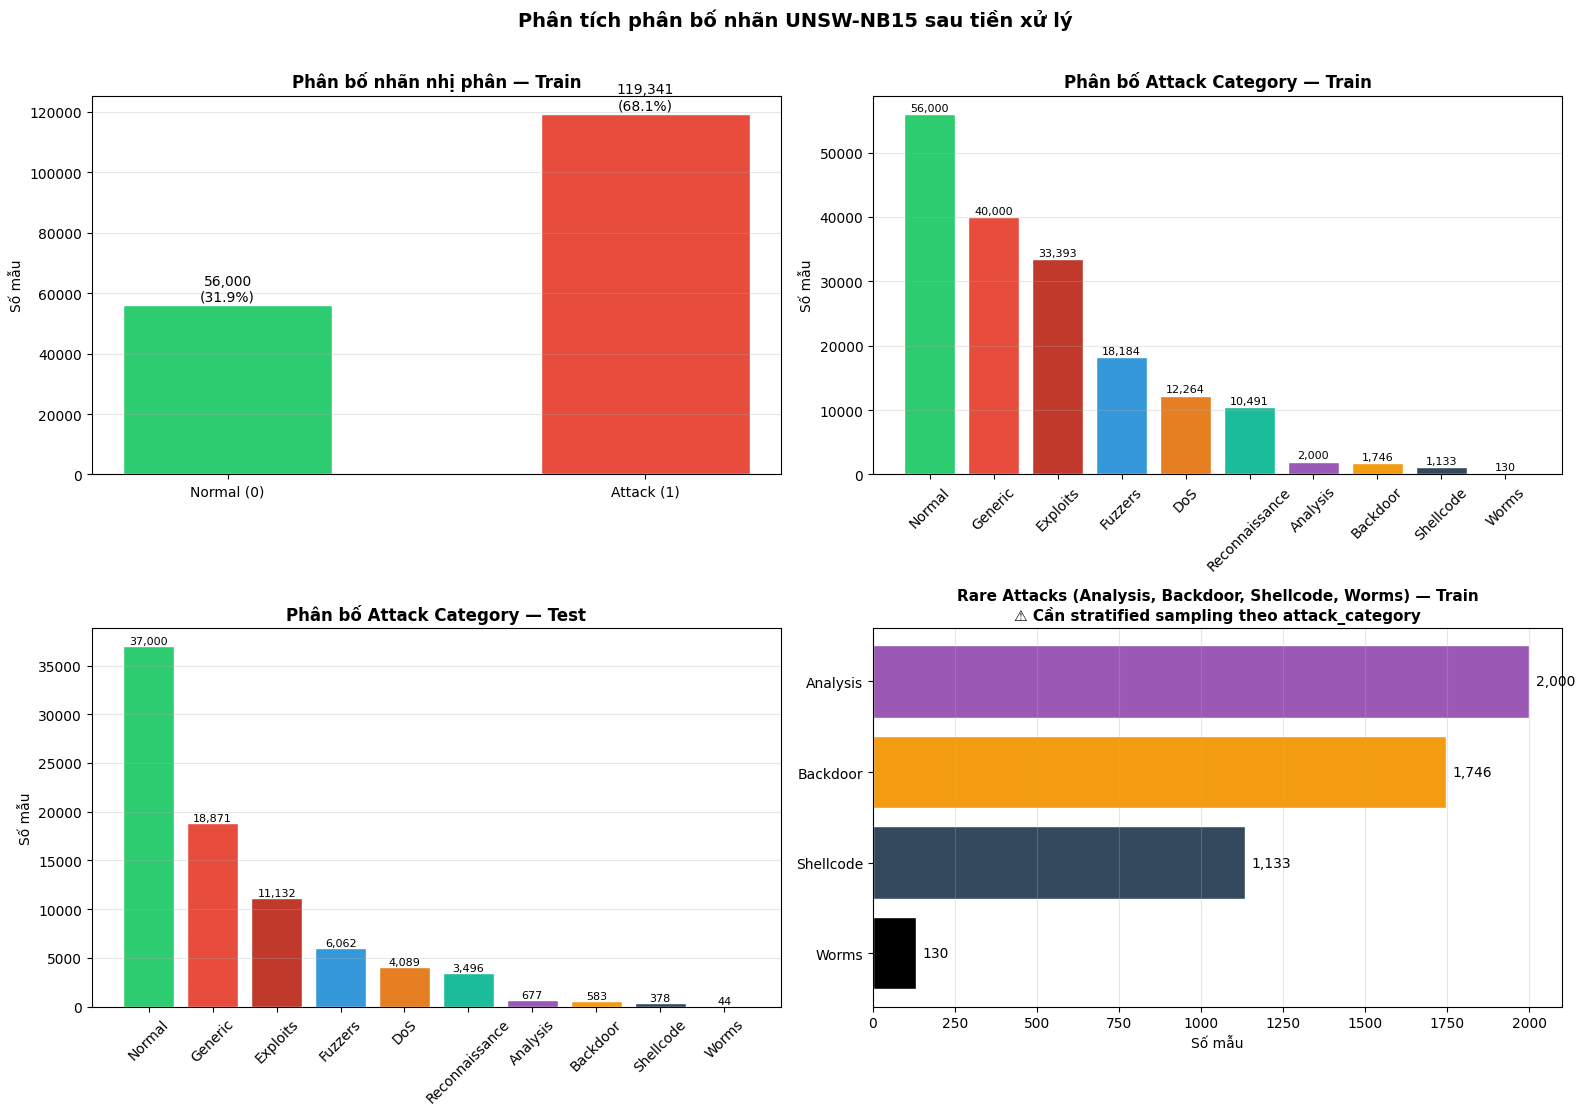

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Bảng màu cho 10 attack categories của UNSW-NB15
CATEGORY_COLORS = {
    'Normal'        : '#2ECC71',
    'Generic'       : '#E74C3C',
    'Exploits'      : '#C0392B',
    'Fuzzers'       : '#3498DB',
    'DoS'           : '#E67E22',
    'Reconnaissance': '#1ABC9C',
    'Analysis'      : '#9B59B6',
    'Backdoor'      : '#F39C12',
    'Shellcode'     : '#34495E',
    'Worms'         : '#000000',
}

# ── Plot 1: Binary label — Train ──
binary_counts = train_clean['label_binary'].value_counts().sort_index()
axes[0,0].bar(['Normal (0)', 'Attack (1)'], binary_counts.values,
              color=['#2ECC71', '#E74C3C'], edgecolor='white', width=0.5)
for i, v in enumerate(binary_counts.values):
    axes[0,0].text(i, v + 1500, f'{v:,}\n({v/len(train_clean)*100:.1f}%)',
                   ha='center', fontsize=10)
axes[0,0].set_title('Phân bố nhãn nhị phân — Train', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Số mẫu')
axes[0,0].grid(axis='y', alpha=0.3)

# ── Plot 2: Attack category — Train ──
cat_counts = train_clean['attack_category'].value_counts()
colors_cat = [CATEGORY_COLORS.get(c, '#95A5A6') for c in cat_counts.index]
axes[0,1].bar(cat_counts.index, cat_counts.values, color=colors_cat, edgecolor='white')
for i, v in enumerate(cat_counts.values):
    axes[0,1].text(i, v + 500, f'{v:,}', ha='center', fontsize=8, rotation=0)
axes[0,1].set_title('Phân bố Attack Category — Train', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Số mẫu')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(axis='y', alpha=0.3)

# ── Plot 3: Attack category — Test ──
cat_counts_t = test_clean['attack_category'].value_counts()
colors_cat_t = [CATEGORY_COLORS.get(c, '#95A5A6') for c in cat_counts_t.index]
axes[1,0].bar(cat_counts_t.index, cat_counts_t.values, color=colors_cat_t, edgecolor='white')
for i, v in enumerate(cat_counts_t.values):
    axes[1,0].text(i, v + 200, f'{v:,}', ha='center', fontsize=8, rotation=0)
axes[1,0].set_title('Phân bố Attack Category — Test', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Số mẫu')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(axis='y', alpha=0.3)

# ── Plot 4: Rare categories zoom-in ──
rare_train = train_clean[train_clean['attack_category'].isin(RARE_CATEGORIES)]
rare_counts = rare_train['attack_category'].value_counts()
colors_rare = [CATEGORY_COLORS.get(c, '#95A5A6') for c in rare_counts.index]
axes[1,1].barh(rare_counts.index, rare_counts.values, color=colors_rare, edgecolor='white')
for i, v in enumerate(rare_counts.values):
    axes[1,1].text(v + 20, i, f'{v:,}', va='center', fontsize=10)
axes[1,1].set_title('Rare Attacks (Analysis, Backdoor, Shellcode, Worms) — Train\n'
                     '⚠ Cần stratified sampling theo attack_category', fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Số mẫu')
axes[1,1].grid(axis='x', alpha=0.3)
axes[1,1].invert_yaxis()

plt.suptitle('Phân tích phân bố nhãn UNSW-NB15 sau tiền xử lý',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Kiểm tra attack categories trong Train vs Test

UNSW-NB15 có cùng 10 categories ở train và test (khác NSL-KDD có nhiều
attack zero-shot trong test) — kiểm tra để xác nhận.

In [7]:
train_cats = set(train_clean['attack_category'].unique())
test_cats  = set(test_clean['attack_category'].unique())

only_in_train = sorted(train_cats - test_cats)
only_in_test  = sorted(test_cats  - train_cats)
in_both       = sorted(train_cats & test_cats)

print(f"Categories trong cả Train và Test ({len(in_both)}):")
print(f"  {in_both}")

if only_in_train:
    print(f"\nChỉ trong Train ({len(only_in_train)}): {only_in_train}")
else:
    print(f"\nChỉ trong Train: (không có)")

if only_in_test:
    print(f"\nChỉ trong Test ({len(only_in_test)}) — zero-shot: {only_in_test}")
else:
    print(f"\nChỉ trong Test: (không có) — toàn bộ test categories đã được học")


Categories trong cả Train và Test (10):
  ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']

Chỉ trong Train: (không có)

Chỉ trong Test: (không có) — toàn bộ test categories đã được học


## 6. Stratified sampling cho QSVM

Hàm lấy mẫu đảm bảo **rare attacks (Analysis, Backdoor, Shellcode, Worms)
có đủ đại diện** — thay vì stratify theo `label_binary` (chỉ đảm bảo tỷ lệ
0:1 chung và sẽ vứt mất các attack hiếm).

In [ ]:
def stratified_sample_for_qsvm(
    df,
    n_samples       = 1000,
    min_rare        = 30,
    rare_categories = RARE_CATEGORIES,
    random_state    = 42,
):
    """Lấy mẫu đảm bảo rare attacks có đại diện.

    Sử dụng Largest Remainder Method (LRM) để phân bổ phần còn lại,
    đảm bảo tổng số mẫu chính xác bằng n_samples (bản gốc dùng int() floor
    cho mỗi category → thiếu mẫu, ra 96-98 thay vì 100).

    Parameters
    ----------
    n_samples       : tổng số mẫu cần lấy
    min_rare        : số mẫu tối thiểu cho MỖI rare category
    rare_categories : các category được ưu tiên oversample
    random_state    : seed để tái lặp
    """
    rng        = np.random.RandomState(random_state)
    sampled    = []
    rare_cats  = [c for c in rare_categories if c in df['attack_category'].unique()]
    other_cats = [c for c in df['attack_category'].unique() if c not in rare_cats]

    # Bước 1: Đảm bảo tối thiểu min_rare mẫu cho mỗi rare category
    rare_budget = 0
    for cat in rare_cats:
        pool    = df[df['attack_category'] == cat]
        n_take  = min(min_rare, len(pool)) if len(pool) >= min_rare else min_rare
        replace = len(pool) < n_take   # oversample khi pool quá nhỏ
        idx     = pool.sample(n=n_take, replace=replace,
                              random_state=rng.randint(1_000_000))
        sampled.append(idx)
        rare_budget += n_take

    # Bước 2: Phần còn lại chia theo tỷ lệ gốc của other categories — Largest Remainder Method
    remaining   = max(0, n_samples - rare_budget)
    other_total = df[df['attack_category'].isin(other_cats)].shape[0]

    if other_total > 0 and remaining > 0:
        # 2a. Tính floor và remainder cho từng category (giữ max(1, ...) để không bỏ category nào)
        allocations = []  # mỗi phần tử: [cat, pool, n_take, remainder]
        for cat in other_cats:
            pool        = df[df['attack_category'] == cat]
            weight      = len(pool) / other_total
            exact       = remaining * weight
            floor_n     = max(1, int(exact))
            remainder   = exact - int(exact)
            allocations.append([cat, pool, floor_n, remainder])

        # 2b. Cân bằng tổng để đúng bằng remaining
        current_total = sum(a[2] for a in allocations)
        deficit       = remaining - current_total

        if deficit > 0:
            # Thiếu → cộng 1 cho các category có remainder lớn nhất
            allocations.sort(key=lambda x: x[3], reverse=True)
            for k in range(deficit):
                allocations[k % len(allocations)][2] += 1
        elif deficit < 0:
            # Thừa (do max(1, ...) đẩy lên) → trừ ở category remainder nhỏ nhất, không xuống dưới 1
            allocations.sort(key=lambda x: x[3])
            need_remove = -deficit
            guard = 0
            while need_remove > 0 and guard < len(allocations) * 100:
                idx = guard % len(allocations)
                if allocations[idx][2] > 1:
                    allocations[idx][2] -= 1
                    need_remove -= 1
                guard += 1

        # 2c. Thực hiện sample với số lượng đã phân bổ
        for cat, pool, n_take, _ in allocations:
            n_take = min(n_take, len(pool))
            idx    = pool.sample(n=n_take,
                                 random_state=rng.randint(1_000_000))
            sampled.append(idx)

    result = pd.concat(sampled).sample(frac=1, random_state=random_state)
    return result.reset_index(drop=True)


sample_1000_path = f'{OUTPUT_DIR}/UNSW_Train_Sample1000.parquet'

if os.path.exists(sample_1000_path):
    print('=== [CACHE] Load lại UNSW_Train_Sample1000.parquet ===')
    sample_1000 = pd.read_parquet(sample_1000_path)
else:
    sample_1000 = stratified_sample_for_qsvm(train_clean, n_samples=1000, min_rare=30)

print("=== Phân bố trong ~1000 mẫu stratified ===")
cat_dist = sample_1000['attack_category'].value_counts()
for cat, cnt in cat_dist.items():
    pct_sample   = cnt / len(sample_1000) * 100
    pct_original = train_clean['attack_category'].value_counts().get(cat, 0) / len(train_clean) * 100
    flag = '⚠ oversampled' if cat in RARE_CATEGORIES and pct_sample > pct_original + 2 else ''
    print(f"  {cat:<16} {cnt:>5} mẫu  ({pct_sample:5.2f}% vs {pct_original:5.2f}% gốc) {flag}")
print(f"\nTổng: {len(sample_1000)} mẫu")
print(f"Số attack categories có mặt: {sample_1000['attack_category'].nunique()}")
print("\n→ Dùng sample_1000 làm input cho SelectKBest và QSVM")

### 6b. Tạo các bộ Train bổ sung (100 / 200 / 500) và bộ Test (100 / 200 / 300)

Dùng cùng `stratified_sample_for_qsvm` để:
- **Train**: 100, 200, 500 mẫu từ `train_clean`
- **Test**: 100, 200, 300 mẫu từ `test_clean`

Tất cả đều đảm bảo 4 rare categories (Analysis, Backdoor, Shellcode, Worms) có đại diện.


In [9]:
TRAIN_SIZES = [100, 200, 500]
TEST_SIZES  = [100, 200, 300]

train_samples, test_samples = {}, {}

print('=== Các bộ TRAIN bổ sung ===')
for n in TRAIN_SIZES:
    path = f'{OUTPUT_DIR}/UNSW_Train_Sample{n}.parquet'
    if os.path.exists(path):
        print(f'  [CACHE] Load UNSW_Train_Sample{n}.parquet')
        s = pd.read_parquet(path)
    else:
        s = stratified_sample_for_qsvm(train_clean, n_samples=n,
                                       min_rare=max(5, n // 20))
    train_samples[n] = s
    cat_dist = s['attack_category'].value_counts()
    print(f'=== Train subset {n} mẫu ===')
    for cat, cnt in cat_dist.items():
        print(f'  {cat:<16} {cnt:>4} mẫu  ({cnt/len(s)*100:.1f}%)')
    print(f'  Tổng thực tế: {len(s)} mẫu\n')

print('=== Các bộ TEST ===')
for n in TEST_SIZES:
    path = f'{OUTPUT_DIR}/UNSW_Test_Sample{n}.parquet'
    if os.path.exists(path):
        print(f'  [CACHE] Load UNSW_Test_Sample{n}.parquet')
        s = pd.read_parquet(path)
    else:
        s = stratified_sample_for_qsvm(test_clean, n_samples=n,
                                       min_rare=max(5, n // 20))
    test_samples[n] = s
    cat_dist = s['attack_category'].value_counts()
    print(f'=== Test subset {n} mẫu ===')
    for cat, cnt in cat_dist.items():
        print(f'  {cat:<16} {cnt:>4} mẫu  ({cnt/len(s)*100:.1f}%)')
    print(f'  Tổng thực tế: {len(s)} mẫu\n')


=== Các bộ TRAIN bổ sung ===
  [CACHE] Load UNSW_Train_Sample100.parquet
=== Train subset 100 mẫu ===
  Normal             26 mẫu  (27.1%)
  Generic            18 mẫu  (18.8%)
  Exploits           15 mẫu  (15.6%)
  Fuzzers             8 mẫu  (8.3%)
  DoS                 5 mẫu  (5.2%)
  Analysis            5 mẫu  (5.2%)
  Shellcode           5 mẫu  (5.2%)
  Worms               5 mẫu  (5.2%)
  Backdoor            5 mẫu  (5.2%)
  Reconnaissance      4 mẫu  (4.2%)
  Tổng thực tế: 96 mẫu

  [CACHE] Load UNSW_Train_Sample200.parquet
=== Train subset 200 mẫu ===
  Normal             52 mẫu  (26.4%)
  Generic            37 mẫu  (18.8%)
  Exploits           31 mẫu  (15.7%)
  Fuzzers            17 mẫu  (8.6%)
  DoS                11 mẫu  (5.6%)
  Backdoor           10 mẫu  (5.1%)
  Worms              10 mẫu  (5.1%)
  Analysis           10 mẫu  (5.1%)
  Shellcode          10 mẫu  (5.1%)
  Reconnaissance      9 mẫu  (4.6%)
  Tổng thực tế: 197 mẫu

  [CACHE] Load UNSW_Train_Sample500.parquet
=== Tr

## 7. Lưu tất cả output (parquet)

Định dạng **parquet** thay cho CSV vì:
- Train có 175k mẫu × ~200 cột (sau OHE) → CSV ~150 MB; parquet ~10–15 MB.
- Đọc parquet nhanh hơn ~10× và giữ nguyên dtype (không phải parse lại float).
- Notebook downstream chỉ cần đổi `pd.read_csv` → `pd.read_parquet`.

In [10]:
feature_cols_out = [c for c in train_clean.columns if c not in LABEL_COLS]

saves = [
    (f'{OUTPUT_DIR}/UNSW_Train_Cleaned.parquet',    train_clean,  train_clean.shape),
    (f'{OUTPUT_DIR}/UNSW_Test_Cleaned.parquet',     test_clean,   test_clean.shape),
    (f'{OUTPUT_DIR}/UNSW_Train_Sample1000.parquet', sample_1000,  sample_1000.shape),
    *[(f'{OUTPUT_DIR}/UNSW_Train_Sample{n}.parquet', train_samples[n], train_samples[n].shape) for n in TRAIN_SIZES],
    *[(f'{OUTPUT_DIR}/UNSW_Test_Sample{n}.parquet',  test_samples[n],  test_samples[n].shape)  for n in TEST_SIZES],
]

print('=== LƯU / KIỂM TRA FILE ===')
for path, df_obj, shape in saves:
    if os.path.exists(path):
        print(f'  [SKIP]  {os.path.basename(path):<42} {str(shape)}  (đã tồn tại)')
    else:
        df_obj.to_parquet(path, index=False)
        print(f'  [SAVE]  {os.path.basename(path):<42} {str(shape)}')

# Scaler
scaler_path = f'{OUTPUT_DIR}/minmax_scaler.joblib'
if os.path.exists(scaler_path):
    print(f'  [SKIP]  {"minmax_scaler.joblib":<42} (đã tồn tại)')
else:
    joblib.dump(scaler, scaler_path)
    print(f'  [SAVE]  {"minmax_scaler.joblib":<42} MinMaxScaler object')

# Feature columns (CSV nhỏ — dễ inspect bằng tay)
feat_path = f'{OUTPUT_DIR}/feature_columns.csv'
if os.path.exists(feat_path):
    print(f'  [SKIP]  {"feature_columns.csv":<42} (đã tồn tại)')
else:
    with open(feat_path, 'w', encoding='utf-8', newline='') as f:
        pd.Series(feature_cols_out).to_csv(f, index=False, header=['feature'])
    print(f'  [SAVE]  {"feature_columns.csv":<42} {len(feature_cols_out)} features')

print(f'\n→ Bước tiếp theo: selectkbest_unsw.ipynb (port từ selectkbest_nslkdd.ipynb)')
print(f'  Input: UNSW_Train_Cleaned.parquet  (toàn bộ train)')
print(f'  Hoặc dùng UNSW_Train_Sample*.parquet / UNSW_Test_Sample*.parquet')


=== LƯU / KIỂM TRA FILE ===
  [SKIP]  UNSW_Train_Cleaned.parquet                 (175341, 189)  (đã tồn tại)
  [SKIP]  UNSW_Test_Cleaned.parquet                  (82332, 189)  (đã tồn tại)
  [SKIP]  UNSW_Train_Sample1000.parquet              (997, 189)  (đã tồn tại)
  [SKIP]  UNSW_Train_Sample100.parquet               (96, 189)  (đã tồn tại)
  [SKIP]  UNSW_Train_Sample200.parquet               (197, 189)  (đã tồn tại)
  [SKIP]  UNSW_Train_Sample500.parquet               (496, 189)  (đã tồn tại)
  [SKIP]  UNSW_Test_Sample100.parquet                (98, 189)  (đã tồn tại)
  [SKIP]  UNSW_Test_Sample200.parquet                (198, 189)  (đã tồn tại)
  [SKIP]  UNSW_Test_Sample300.parquet                (299, 189)  (đã tồn tại)
  [SKIP]  minmax_scaler.joblib                       (đã tồn tại)
  [SKIP]  feature_columns.csv                        (đã tồn tại)

→ Bước tiếp theo: selectkbest_unsw.ipynb (port từ selectkbest_nslkdd.ipynb)
  Input: UNSW_Train_Cleaned.parquet  (toàn bộ train)
  Hoặ

## 8. Tạo 5 tập Train + 5 tập Test không trùng nhau (n=100)

Phục vụ multi-run evaluation — đảm bảo các run **disjoint** (không sample
trùng) bằng cách partition trước rồi mới stratified-sample trong từng partition.

In [11]:
N_RUNS    = 5
RUN_SIZE  = 100
MIN_RARE  = max(5, RUN_SIZE // 20)
MULTI_DIR = f'{OUTPUT_DIR}/multi_run'
os.makedirs(MULTI_DIR, exist_ok=True)


def make_disjoint_runs(df, n_runs=5, run_size=100, min_rare=5,
                       base_seed=0, split_name='set'):
    """Partition df rồi stratified-sample trong từng partition.

    Tính disjoint giữa các run được đảm bảo BẰNG CẤU TRÚC: ta slice
    `df.iloc[start:end]` trên df đã shuffle → partitions không giao nhau →
    samples lấy từ trong từng partition cũng không giao nhau theo source row.

    Lưu ý: KHÔNG kiểm disjoint bằng hash của feature tuple — UNSW-NB15
    có nhiều flow trùng feature vector (sau OHE + MinMax) nên check đó
    sẽ false-positive.
    """
    df_shuffled = df.sample(frac=1, random_state=base_seed).reset_index(drop=True)
    total       = len(df_shuffled)
    part_size   = total // n_runs

    runs = []
    partition_index_sets = []
    for i in range(n_runs):
        start = i * part_size
        end   = (i + 1) * part_size if i < n_runs - 1 else total
        partition = df_shuffled.iloc[start:end].copy()
        partition_index_sets.append(set(partition.index.tolist()))

        run_df = stratified_sample_for_qsvm(
            partition,
            n_samples    = run_size,
            min_rare     = min_rare,
            random_state = base_seed + i,
        )
        runs.append(run_df)
        print(f'  [{split_name} run {i+1}] partition={len(partition):>6}  '
              f'sample={len(run_df)}  '
              f'dist={dict(run_df["attack_category"].value_counts())}')

    # Assert partitions disjoint (luôn đúng theo cách iloc slice — đây là sanity guard)
    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            ov = partition_index_sets[i] & partition_index_sets[j]
            assert not ov, f'Partition {i+1} ∩ {j+1} = {len(ov)} (không nên xảy ra)'
    return runs


all_files = [f'{MULTI_DIR}/train_run{i}.parquet' for i in range(1, N_RUNS + 1)] + \
            [f'{MULTI_DIR}/test_run{i}.parquet'  for i in range(1, N_RUNS + 1)]
files_exist = all(os.path.exists(f) for f in all_files)

if files_exist:
    print('=== [CACHE] Phát hiện file đã tồn tại — bỏ qua tạo mới, load lại ===\n')
    train_runs, test_runs = [], []
    print('=== Load 5 tập TRAIN ===')
    for i in range(1, N_RUNS + 1):
        df = pd.read_parquet(f'{MULTI_DIR}/train_run{i}.parquet')
        train_runs.append(df)
        print(f'  [TRAIN run {i}] shape={df.shape}  '
              f'dist={dict(df["attack_category"].value_counts())}')

    print('\n=== Load 5 tập TEST ===')
    for i in range(1, N_RUNS + 1):
        df = pd.read_parquet(f'{MULTI_DIR}/test_run{i}.parquet')
        test_runs.append(df)
        print(f'  [TEST  run {i}] shape={df.shape}  '
              f'dist={dict(df["attack_category"].value_counts())}')
else:
    print('=== Tạo 5 tập TRAIN (size=100, disjoint) ===')
    train_runs = make_disjoint_runs(train_clean, n_runs=N_RUNS, run_size=RUN_SIZE,
                                    min_rare=MIN_RARE, base_seed=100, split_name='TRAIN')

    print('\n=== Tạo 5 tập TEST (size=100, disjoint) ===')
    test_runs = make_disjoint_runs(test_clean, n_runs=N_RUNS, run_size=RUN_SIZE,
                                   min_rare=MIN_RARE, base_seed=200, split_name='TEST ')

    print(f'\n=== Lưu vào {MULTI_DIR} ===')
    for i, (tr, te) in enumerate(zip(train_runs, test_runs), start=1):
        tr.to_parquet(f'{MULTI_DIR}/train_run{i}.parquet', index=False)
        te.to_parquet(f'{MULTI_DIR}/test_run{i}.parquet',  index=False)
        print(f'  [run {i}]  train_run{i}.parquet ({tr.shape})   test_run{i}.parquet ({te.shape})')

    print('\n  [✓] Disjointness được đảm bảo bằng cấu trúc iloc slice — '
          'mọi assert đã pass trong make_disjoint_runs')

print(f'\n→ Sẵn sàng dùng cho QSVM multi-run evaluation')
print(f'   Input pattern: {MULTI_DIR}/train_run{{1..5}}.parquet + test_run{{1..5}}.parquet')


=== [CACHE] Phát hiện file đã tồn tại — bỏ qua tạo mới, load lại ===

=== Load 5 tập TRAIN ===
  [TRAIN run 1] shape=(97, 189)  dist={'Normal': np.int64(26), 'Generic': np.int64(18), 'Exploits': np.int64(15), 'Fuzzers': np.int64(8), 'Reconnaissance': np.int64(5), 'Backdoor': np.int64(5), 'Shellcode': np.int64(5), 'Analysis': np.int64(5), 'DoS': np.int64(5), 'Worms': np.int64(5)}
  [TRAIN run 2] shape=(96, 189)  dist={'Normal': np.int64(26), 'Generic': np.int64(18), 'Exploits': np.int64(15), 'Fuzzers': np.int64(8), 'Backdoor': np.int64(5), 'DoS': np.int64(5), 'Worms': np.int64(5), 'Analysis': np.int64(5), 'Shellcode': np.int64(5), 'Reconnaissance': np.int64(4)}
  [TRAIN run 3] shape=(96, 189)  dist={'Normal': np.int64(26), 'Generic': np.int64(18), 'Exploits': np.int64(15), 'Fuzzers': np.int64(8), 'Shellcode': np.int64(5), 'Worms': np.int64(5), 'DoS': np.int64(5), 'Analysis': np.int64(5), 'Backdoor': np.int64(5), 'Reconnaissance': np.int64(4)}
  [TRAIN run 4] shape=(96, 189)  dist={'Norm

## 9. Sanity checks — chạy trước khi sang `selectkbest_unsw.ipynb`

In [12]:
print("=== SANITY CHECKS ===")
checks = []

# Check 1: Feature range [0, 1]
feat_min = train_clean[feature_cols_out].min().min()
feat_max = train_clean[feature_cols_out].max().max()
ok1 = abs(feat_min) < 1e-9 and abs(feat_max - 1.0) < 1e-9
checks.append(('Feature range [0, 1]', ok1, f'min={feat_min:.6f}, max={feat_max:.6f}'))

# Check 2: Không có NaN trong features
nan_feat = train_clean[feature_cols_out].isna().sum().sum()
checks.append(('Không có NaN trong train features', nan_feat == 0, f'{nan_feat} NaN'))

nan_feat_test = test_clean[feature_cols_out].isna().sum().sum()
checks.append(('Không có NaN trong test features',  nan_feat_test == 0, f'{nan_feat_test} NaN'))

# Check 3: label_binary chỉ có {0, 1}
binary_vals = set(train_clean['label_binary'].unique())
checks.append(('label_binary chỉ có {0, 1}', binary_vals == {0, 1}, str(binary_vals)))

# Check 4: Số cột train = test
same_cols = list(train_clean[feature_cols_out].columns) == list(test_clean[feature_cols_out].columns)
checks.append(('Số feature columns train = test', same_cols, f'{len(feature_cols_out)} cột'))

# Check 5: label_binary nhất quán với attack_category (Normal ↔ 0)
mismatch = ((train_clean['attack_category'] == 'Normal') &
            (train_clean['label_binary'] == 1)).sum()
mismatch += ((train_clean['attack_category'] != 'Normal') &
             (train_clean['label_binary'] == 0)).sum()
checks.append(('label_binary nhất quán với attack_category', mismatch == 0,
               f'{mismatch} mẫu sai'))

# Check 6: Sample 1000 có đủ ≥ số rare categories có mặt trong train
expected_rare_in_sample = sum(1 for c in RARE_CATEGORIES if c in train_clean['attack_category'].unique())
rare_in_sample = sum(1 for c in RARE_CATEGORIES if c in sample_1000['attack_category'].unique())
checks.append((f'Sample 1000 có đủ {expected_rare_in_sample}/{len(RARE_CATEGORIES)} rare cats',
               rare_in_sample == expected_rare_in_sample,
               f'{rare_in_sample}/{expected_rare_in_sample} rare cats'))

# Check 7: Cột nhãn không rò rỉ vào features
leaked = [c for c in LABEL_COLS if c in feature_cols_out]
leaked += [c for c in [RAW_LABEL_COL, RAW_ATTACK_CAT_COL] if c in feature_cols_out]
checks.append(('Không có cột nhãn rò rỉ vào features', len(leaked) == 0,
               'OK' if len(leaked) == 0 else f'leaked: {leaked}'))

all_ok = True
for name, ok, detail in checks:
    status = '✓' if ok else '✗'
    print(f"  [{status}] {name:<50} {detail}")
    if not ok:
        all_ok = False

print()
if all_ok:
    print("  Tất cả checks PASSED — sẵn sàng sang selectkbest_unsw.ipynb")
else:
    print("  ⚠ Có check FAILED — kiểm tra lại trước khi tiếp tục")


=== SANITY CHECKS ===
  [✓] Feature range [0, 1]                               min=0.000000, max=1.000000
  [✓] Không có NaN trong train features                  0 NaN
  [✓] Không có NaN trong test features                   0 NaN
  [✓] label_binary chỉ có {0, 1}                         {np.int64(0), np.int64(1)}
  [✓] Số feature columns train = test                    186 cột
  [✓] label_binary nhất quán với attack_category         0 mẫu sai
  [✓] Sample 1000 có đủ 4/4 rare cats                    4/4 rare cats
  [✓] Không có cột nhãn rò rỉ vào features               OK

  Tất cả checks PASSED — sẵn sàng sang selectkbest_unsw.ipynb
